# Neuromorphic Obstacle Prediction — Data Preprocessing & SNN Training

This notebook:
1. Loads and cleans ultrasonic sensor data from an AUV.
2. Engineers temporal features (`delta`, `velocity`, `acceleration`, …).
3. Builds sliding-window sequences with a configurable **prediction horizon**.
4. Trains an **event-driven Spiking Neural Network (SNN)** using *Send-on-Delta* encoding.
5. Compares `PRED_HORIZON = 0` (current detection) vs `PRED_HORIZON = 5` (future prediction).

> **Prerequisites** — install before running:
> `pip install torch torchvision torchaudio snntorch scikit-learn pandas numpy matplotlib seaborn joblib`

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import snntorch as snn
from snntorch import surrogate

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

## 2. Data Loading & Cleaning

Steps:
- Drop the CSV index artifact column (`Unnamed: 0`).
- Keep only **valid** readings (`valid == 1`).
- Remove rows recorded **before the baseline was learned** (`baseline_cm > 0`).
- Clamp filtered distance to the physically plausible range **20 – 600 cm**.

In [2]:
df = pd.read_csv("sensor.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
print("Original shape:", df.shape)

# Keep only valid readings
df = df[df["valid"] == 1].copy()

# Remove rows before baseline is learned
df = df[df["baseline_cm"] > 0].copy()

# Remove impossible distances
df = df[(df["dist_f_cm"] > 20) & (df["dist_f_cm"] <= 600)].copy()

print("After cleaning:", df.shape)
print(df.head())

Original shape: (27150, 14)
After cleaning: (23014, 14)
    session_id          run_type scenario  time_ms  sensor_id  echo_us  valid  \
37           1  C_front_far_deep     safe    31798          1     3646      1   
38           1  C_front_far_deep     safe    32080          1     3629      1   
39           1  C_front_far_deep     safe    32363          1     3657      1   
40           1  C_front_far_deep     safe    32632          1     3659      1   
41           1  C_front_far_deep     safe    32902          1     3627      1   

    dist_cm  dist_f_cm  baseline_cm  enter_thr_cm  exit_thr_cm  danger  event  
37    269.8      267.5        268.3         120.0        140.0     0.0      0  
38    268.5      267.8        268.3         208.3        228.3     0.0      0  
39    270.6      268.5        268.3         208.3        228.3     0.0      0  
40    270.8      269.1        268.3         208.3        228.3     0.0      0  
41    268.4      268.9        268.3         208.3        

## 3. Feature Engineering

| Feature | Description |
|---------|-------------|
| `delta` | `dist_f_cm − baseline_cm` — deviation from baseline |
| `dist_to_enter` | distance to the enter-threshold |
| `dist_to_exit` | distance to the exit-threshold |
| `time_gap` | time difference between consecutive readings (per session) |
| `velocity` | rate of change of filtered distance |
| `acceleration` | rate of change of velocity |

In [3]:
# Group column for session-aware computations
group_cols = []
if "session_id" in df.columns:
    group_cols.append("session_id")

# Distance deviation from baseline
df["delta"] = df["dist_f_cm"] - df["baseline_cm"]

# Distance to thresholds
df["dist_to_enter"] = df["dist_f_cm"] - df["enter_thr_cm"]
df["dist_to_exit"]  = df["dist_f_cm"] - df["exit_thr_cm"]

# Time gap (per session) — with fallback when no session column exists
if group_cols:
    df["time_gap"] = df.groupby(group_cols)["time_ms"].diff()
else:
    df["time_gap"] = df["time_ms"].diff()
df = df.dropna(subset=["time_gap"])

# Guard against zero time_gap (duplicate timestamps) to avoid inf/NaN
df["time_gap"] = df["time_gap"].replace(0, np.nan)
df = df.dropna(subset=["time_gap"])

# Velocity & acceleration
if group_cols:
    df["velocity"]     = df.groupby(group_cols)["dist_f_cm"].diff() / df["time_gap"]
    df["acceleration"] = df.groupby(group_cols)["velocity"].diff()  / df["time_gap"]
else:
    df["velocity"]     = df["dist_f_cm"].diff() / df["time_gap"]
    df["acceleration"] = df["velocity"].diff()  / df["time_gap"]
df = df.dropna(subset=["velocity", "acceleration"])

print("After feature engineering:", df.shape)
print(df.head())

After feature engineering: (22744, 20)
    session_id          run_type scenario  time_ms  sensor_id  echo_us  valid  \
40           1  C_front_far_deep     safe    32632          1     3659      1   
41           1  C_front_far_deep     safe    32902          1     3627      1   
42           1  C_front_far_deep     safe    33190          1     3656      1   
43           1  C_front_far_deep     safe    33476          1     3667      1   
44           1  C_front_far_deep     safe    33759          1     3679      1   

    dist_cm  dist_f_cm  baseline_cm  enter_thr_cm  exit_thr_cm  danger  event  \
40    270.8      269.1        268.3         208.3        228.3     0.0      0   
41    268.4      268.9        268.3         208.3        228.3     0.0      0   
42    270.5      269.3        268.3         208.3        228.3     0.0      0   
43    271.4      269.8        268.3         208.3        228.3     0.0      0   
44    272.2      270.4        268.3         208.3        228.3     0.

## 4. Feature & Label Selection

In [4]:
feature_cols = ["time_gap", "dist_f_cm", "delta", "velocity", "acceleration"]

if "state" not in df.columns:
    df["state"] = (df["danger"] > 0).astype(int)
label_col = "state"  # always set, regardless of whether 'state' already existed

print("Features:", feature_cols)
print("Label:   ", label_col)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:  ", device)

Features: ['time_gap', 'dist_f_cm', 'delta', 'velocity', 'acceleration']
Label:    state
Device:   cpu


## 5. Send-on-Delta Encoder

Converts a continuous-valued window `(batch, time_steps, features)` into binary
ON / OFF spikes `(batch, time_steps, features × 2)`.  A spike is emitted
whenever the change from the last reference exceeds a threshold.

In [5]:
def delta_encoder(x, threshold):
    # Send-on-Delta modulation: continuous -> ON/OFF spikes.
    batch_size, time_steps, features = x.shape
    spikes = torch.zeros((batch_size, time_steps, features * 2), device=x.device)
    reference = x[:, 0, :]

    for t in range(1, time_steps):
        current_val = x[:, t, :]
        diff = current_val - reference
        on_spikes  = (diff >=  threshold).float()
        off_spikes = (diff <= -threshold).float()
        spike_mask = torch.logical_or(on_spikes > 0, off_spikes > 0).float()
        reference  = reference * (1 - spike_mask) + current_val * spike_mask
        spikes[:, t, :features] = on_spikes
        spikes[:, t, features:] = off_spikes

    return spikes

## 6. Event-Driven SNN Architecture

Three fully-connected layers interleaved with Leaky Integrate-and-Fire (LIF)
neurons.  The **input** is the spike-encoded signal from `delta_encoder`, so the
first layer has `input_size × 2` inputs.  The **output** is the membrane
potential of the final LIF layer at the last time step.

In [6]:
class EventDrivenSNN(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, output_size=2,
                 beta=0.9, encode_threshold=0.5):
        super().__init__()
        self.encode_threshold = encode_threshold
        self.fc1 = nn.Linear(input_size * 2, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        spike_grad = surrogate.fast_sigmoid()
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        spk_in = delta_encoder(x, self.encode_threshold)
        time_steps = spk_in.size(1)
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem3_rec = []
        for t in range(time_steps):
            cur1 = self.fc1(spk_in[:, t, :])
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.fc3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            mem3_rec.append(mem3)
        return torch.stack(mem3_rec, dim=0)  # (time_steps, batch, output_size)

## 7. Helper Functions

- **`build_windows`** — creates sliding-window sequences, returning per-window session IDs for later splitting.
- **`session_based_split`** — splits by *session*, so no session straddles train / val / test.
- **`train_one_epoch`** / **`evaluate`** — standard PyTorch train / eval loops.

In [7]:
# ───────── Window builder ─────────
def build_windows(df, feature_cols, label_col, group_cols,
                  window_size, step_size, pred_horizon):
    X, y, sids = [], [], []
    for group_key, group in df.groupby(group_cols):
        group = group.sort_values("time_ms").reset_index(drop=True)
        if len(group) < window_size + pred_horizon:
            continue
        sid = group_key if not isinstance(group_key, tuple) else group_key[0]
        for start in range(0, len(group) - window_size - pred_horizon + 1, step_size):
            end = start + window_size
            label_idx = end - 1 + pred_horizon
            X.append(group.iloc[start:end][feature_cols].values)
            y.append(group.iloc[label_idx][label_col])
            sids.append(sid)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64), np.array(sids)


# ───────── Session-based split ─────────
def session_based_split(X, y, session_ids,
                        train_ratio=0.70, val_ratio=0.15, seed=42):
    unique = np.unique(session_ids)
    rng = np.random.RandomState(seed)
    rng.shuffle(unique)
    n = len(unique)

    # Ensure at least 1 session in val and test
    train_end = max(1, int(train_ratio * n))
    val_end   = max(train_end + 1, int((train_ratio + val_ratio) * n))
    if val_end >= n:
        val_end = n - 1          # leave at least 1 for test
    if train_end >= val_end:
        train_end = val_end - 1  # leave at least 1 for val

    train_s = set(unique[:train_end])
    val_s   = set(unique[train_end:val_end])
    test_s  = set(unique[val_end:])

    train_mask = np.isin(session_ids, list(train_s))
    val_mask   = np.isin(session_ids, list(val_s))
    test_mask  = np.isin(session_ids, list(test_s))

    return (X[train_mask], y[train_mask],
            X[val_mask],   y[val_mask],
            X[test_mask],  y[test_mask],
            train_s, val_s, test_s)


# ───────── Training loop ─────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = model(xb)[-1]       # last time-step membrane potential
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        all_preds.extend(torch.argmax(output, 1).cpu().numpy())
        all_labels.extend(yb.cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)


# ───────── Evaluation loop ─────────
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)[-1]
            loss = criterion(output, yb)
            running_loss += loss.item() * xb.size(0)
            all_preds.extend(torch.argmax(output, 1).cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    return running_loss / len(loader.dataset), accuracy_score(all_labels, all_preds), all_labels, all_preds

## 8. Full Training Pipeline

`run_pipeline` encapsulates windowing → splitting → scaling → training → evaluation
for a given `pred_horizon`, returning a results dict.

In [8]:
WINDOW_SIZE = 15
STEP_SIZE   = 5
NUM_EPOCHS  = 20
BATCH_SIZE  = 64

def run_pipeline(pred_horizon):
    print(f"\n{'=' * 60}")
    print(f"  PRED_HORIZON = {pred_horizon}")
    print(f"{'=' * 60}\n")

    # 1. Build windows
    X, y, sids = build_windows(df, feature_cols, label_col, group_cols,
                               WINDOW_SIZE, STEP_SIZE, pred_horizon)
    print(f"Windows: {X.shape[0]}  |  Shape: {X.shape}")
    uniq, cnts = np.unique(y, return_counts=True)
    print(f"Labels:  {dict(zip(uniq, cnts))}")

    # 2. Session-based split
    (X_tr, y_tr, X_va, y_va, X_te, y_te,
     tr_s, va_s, te_s) = session_based_split(X, y, sids)
    print(f"\nTrain sessions: {sorted(tr_s)}  ({X_tr.shape[0]} windows)")
    print(f"Val   sessions: {sorted(va_s)}  ({X_va.shape[0]} windows)")
    print(f"Test  sessions: {sorted(te_s)}  ({X_te.shape[0]} windows)")
    assert not (tr_s & va_s) and not (tr_s & te_s) and not (va_s & te_s), \
        "Session overlap!"

    # 3. Normalise (fit on train only)
    n_tr, t_dim, f_dim = X_tr.shape
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr.reshape(-1, f_dim)).reshape(n_tr, t_dim, f_dim)
    X_va_s = scaler.transform(X_va.reshape(-1, f_dim)).reshape(X_va.shape)
    X_te_s = scaler.transform(X_te.reshape(-1, f_dim)).reshape(X_te.shape)

    # 4. DataLoaders
    mk = lambda x, y, shuf: DataLoader(
        TensorDataset(torch.tensor(x, dtype=torch.float32),
                      torch.tensor(y, dtype=torch.long)),
        batch_size=BATCH_SIZE, shuffle=shuf)
    train_dl = mk(X_tr_s, y_tr, True)
    val_dl   = mk(X_va_s, y_va, False)
    test_dl  = mk(X_te_s, y_te, False)

    # 5. Class weights
    cw = compute_class_weight("balanced",
                              classes=np.unique(y_tr), y=y_tr)
    cw_t = torch.tensor(cw, dtype=torch.float32).to(device)
    print(f"Class weights: {cw_t}")
    criterion = nn.CrossEntropyLoss(weight=cw_t)

    # 6. Model & optimiser
    model = EventDrivenSNN(input_size=len(feature_cols),
                           hidden_size=32, output_size=2, beta=0.9).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    # 7. Training loop
    hist = {"tl": [], "vl": [], "ta": [], "va": []}
    for ep in range(1, NUM_EPOCHS + 1):
        tl, ta = train_one_epoch(model, train_dl, opt, criterion)
        vl, va, _, _ = evaluate(model, val_dl, criterion)
        hist["tl"].append(tl); hist["vl"].append(vl)
        hist["ta"].append(ta); hist["va"].append(va)
        print(f"Epoch [{ep:>2}/{NUM_EPOCHS}] "
              f"TrLoss {tl:.4f} | TrAcc {ta:.4f} | "
              f"VaLoss {vl:.4f} | VaAcc {va:.4f}")

    # 8. Test evaluation
    te_loss, te_acc, y_true, y_pred = evaluate(model, test_dl, criterion)
    print(f"\nTest Loss: {te_loss:.4f}  |  Test Acc: {te_acc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=["Safe", "Danger"]))
    cm = confusion_matrix(y_true, y_pred)

    # 9. Plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(hist["tl"], label="Train"); axes[0].plot(hist["vl"], label="Val")
    axes[0].legend(); axes[0].set_title(f"Loss  (horizon={pred_horizon})")
    axes[1].plot(hist["ta"], label="Train"); axes[1].plot(hist["va"], label="Val")
    axes[1].legend(); axes[1].set_title(f"Accuracy  (horizon={pred_horizon})")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Safe","Danger"],
                yticklabels=["Safe","Danger"], ax=axes[2])
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
    axes[2].set_title(f"Confusion Matrix  (horizon={pred_horizon})")
    plt.tight_layout(); plt.show()

    return dict(pred_horizon=pred_horizon, test_acc=te_acc, test_loss=te_loss,
                y_true=y_true, y_pred=y_pred, model=model, scaler=scaler)

## 9. Run Experiments — `PRED_HORIZON` Comparison

Train and evaluate the SNN with two horizons:
| Horizon | Meaning |
|---------|---------|
| **0** | Classify the danger state at the *end* of the current window (detection). |
| **5** | Classify the danger state **5 time-steps ahead** (prediction). |


  PRED_HORIZON = 0

Windows: 4331  |  Shape: (4331, 15, 5)
Labels:  {np.int64(0): np.int64(3521), np.int64(1): np.int64(810)}

Train sessions: [np.int64(1), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(31), np.int64(32), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(39), np.int64(40), np.int64(41), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(50), np.int64(51), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(62), np.int64(63), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(74), np.int64(76), np.int64(77), np.int64(79), np.int64(81), np.int64(82), np.int64(85), np.int64(87), np.int64(88), np.int64

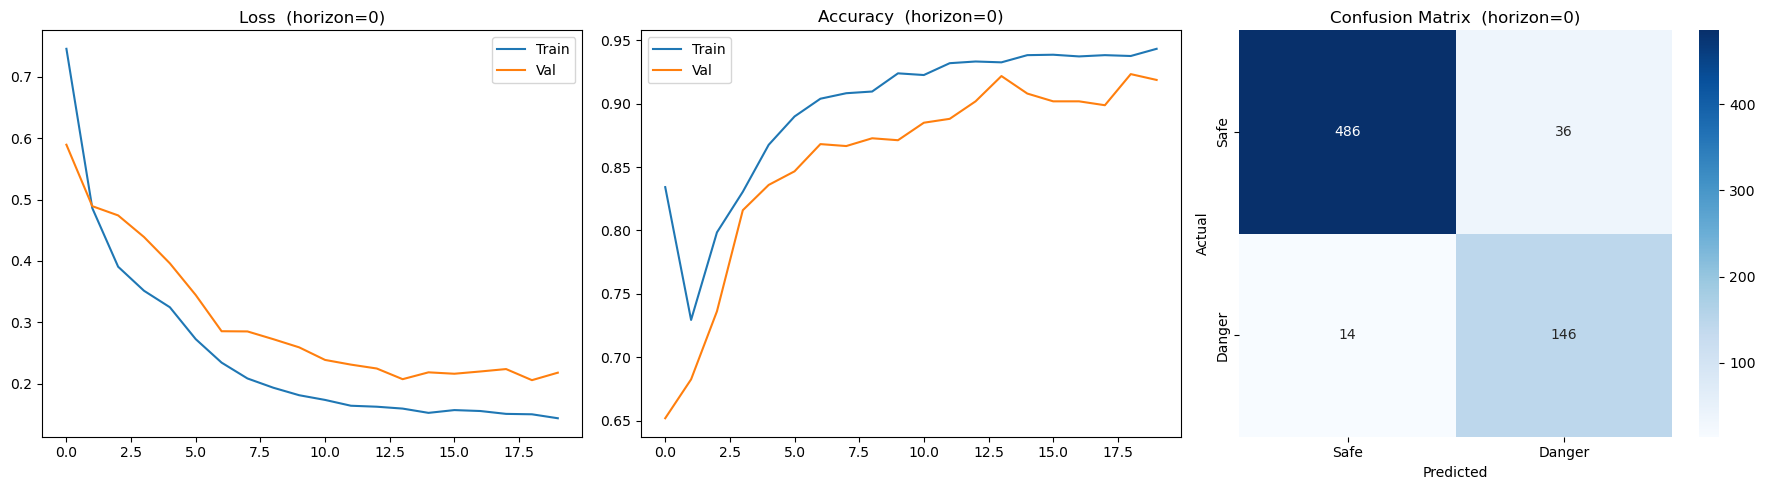


  PRED_HORIZON = 5

Windows: 4241  |  Shape: (4241, 15, 5)
Labels:  {np.int64(0): np.int64(3431), np.int64(1): np.int64(810)}

Train sessions: [np.int64(1), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(31), np.int64(32), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(39), np.int64(40), np.int64(41), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(50), np.int64(51), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(62), np.int64(63), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(74), np.int64(76), np.int64(77), np.int64(79), np.int64(81), np.int64(82), np.int64(85), np.int64(87), np.int64(88), np.int64

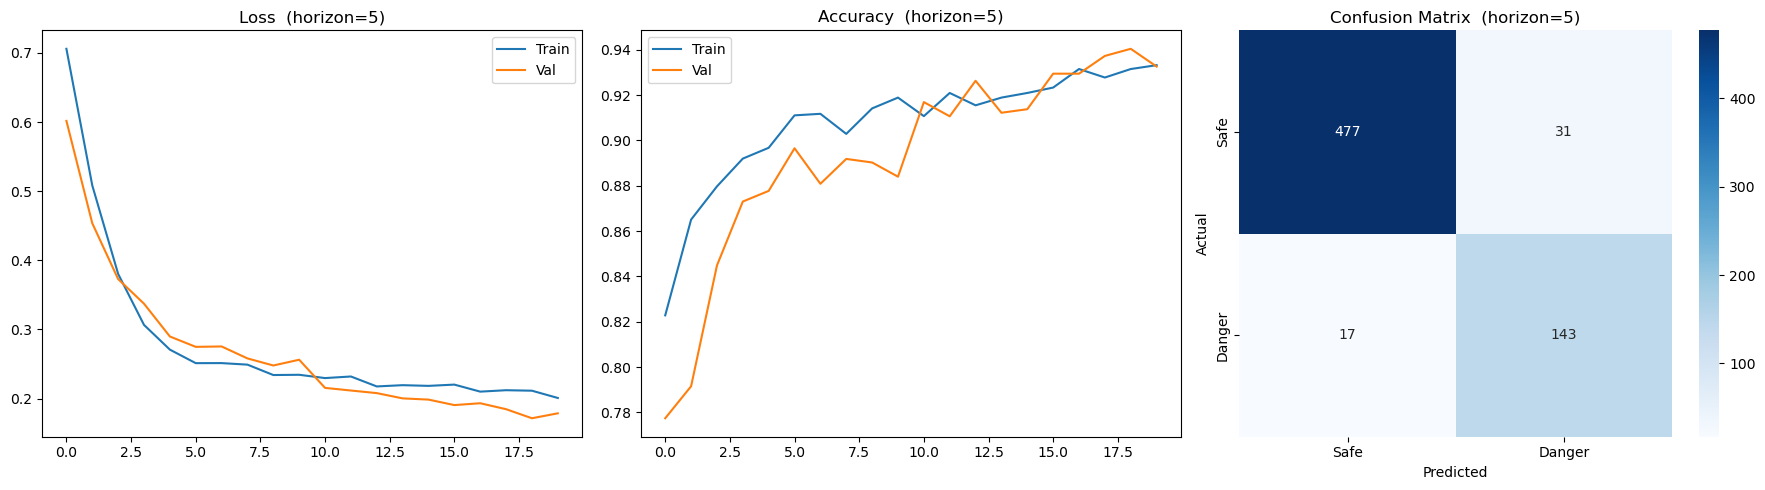

In [9]:
results = {}
for ph in [0,5]:
    results[ph] = run_pipeline(ph)

## 10. Results Comparison

In [10]:
print(f"\n{'=' * 60}")
print(f"  PRED_HORIZON COMPARISON")
print(f"{'=' * 60}")
print(f"\n{'Metric':<25} {'HORIZON=0':>12} {'HORIZON=5':>12}")
print("-" * 50)
print(f"{'Test Accuracy':<25} {results[0]['test_acc']:>12.4f} {results[5]['test_acc']:>12.4f}")
print(f"{'Test Loss':<25} {results[0]['test_loss']:>12.4f} {results[5]['test_loss']:>12.4f}")

for ph in [0, 5]:
    rpt = classification_report(results[ph]["y_true"], results[ph]["y_pred"],
                                target_names=["Safe", "Danger"], output_dict=True)
    print(f"\nPRED_HORIZON = {ph}:")
    print(f"  Safe   — P: {rpt['Safe']['precision']:.4f}  "
          f"R: {rpt['Safe']['recall']:.4f}  F1: {rpt['Safe']['f1-score']:.4f}")
    print(f"  Danger — P: {rpt['Danger']['precision']:.4f}  "
          f"R: {rpt['Danger']['recall']:.4f}  F1: {rpt['Danger']['f1-score']:.4f}")


  PRED_HORIZON COMPARISON

Metric                       HORIZON=0    HORIZON=5
--------------------------------------------------
Test Accuracy                   0.9267       0.9281
Test Loss                       0.1989       0.2190

PRED_HORIZON = 0:
  Safe   — P: 0.9720  R: 0.9310  F1: 0.9511
  Danger — P: 0.8022  R: 0.9125  F1: 0.8538

PRED_HORIZON = 5:
  Safe   — P: 0.9656  R: 0.9390  F1: 0.9521
  Danger — P: 0.8218  R: 0.8938  F1: 0.8563


## 11. Save Model & Scaler

The checkpoint includes full architecture metadata so it can be loaded
without knowing the training configuration.

In [11]:
best_ph = max(results, key=lambda k: results[k]["test_acc"])
print(f"Best horizon: {best_ph}  (Test Acc: {results[best_ph]['test_acc']:.4f})")

checkpoint = {
    "model_class":      "EventDrivenSNN",
    "model_state_dict": results[best_ph]["model"].state_dict(),
    "feature_cols":     feature_cols,
    "window_size":      WINDOW_SIZE,
    "step_size":        STEP_SIZE,
    "pred_horizon":     best_ph,
    "input_size":       len(feature_cols),
    "hidden_size":      32,
    "output_size":      2,
    "beta":             0.9,
    "encode_threshold": 0.5,
    "test_accuracy":    results[best_ph]["test_acc"],
}
torch.save(checkpoint, "snn_obstacle_model.pth")
joblib.dump(results[best_ph]["scaler"], "feature_scaler.pkl")
print("Saved: snn_obstacle_model.pth, feature_scaler.pkl")

Best horizon: 5  (Test Acc: 0.9281)
Saved: snn_obstacle_model.pth, feature_scaler.pkl


---
## 12. Baseline Comparison — RF · LSTM · MLP · SNN

These cells extend the existing notebook.
They train RF / LSTM / MLP on the **exact same split and scaler** that
`run_pipeline(0)` used, so every model is evaluated on identical criteria.

> Run cells 12 → 15 in order **after** Cell 11 (Save Model).


### 12.1  Shared Setup — Rebuild Split from Saved Pipeline

In [12]:
import time, warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ── Which horizon to evaluate (detection task) ────────────────────────
ph = 0

# ── Recover the trained SNN and its scaler ────────────────────────────
# run_pipeline returns: pred_horizon, test_acc, test_loss,
#                       y_true, y_pred, model, scaler
# It does NOT store X_tr/X_te — we rebuild them here using the same
# build_windows + session_based_split + scaler as run_pipeline did.
SNN_MODEL = results[ph]["model"]
SNN_MODEL.eval()
saved_scaler = results[ph]["scaler"]

# ── Rebuild windows (identical to run_pipeline internals) ─────────────
X_all, y_all, sids_all = build_windows(
    df, feature_cols, label_col, group_cols,
    WINDOW_SIZE, STEP_SIZE, pred_horizon=ph)

# ── Rebuild the exact same session split (same seed=42) ───────────────
(X_tr, y_tr, X_va, y_va, X_te, y_te,
 tr_s, va_s, te_s) = session_based_split(X_all, y_all, sids_all)

# ── Apply the saved scaler (fit already happened on train) ────────────
n_tr, t_dim, f_dim = X_tr.shape
X_tr = saved_scaler.transform(X_tr.reshape(-1, f_dim)).reshape(n_tr, t_dim, f_dim)
X_va = saved_scaler.transform(X_va.reshape(-1, f_dim)).reshape(X_va.shape)
X_te = saved_scaler.transform(X_te.reshape(-1, f_dim)).reshape(X_te.shape)

print(f"Rebuilt split for HORIZON={ph}:")
print(f"  Train : {len(X_tr):,} windows  "
      f"Safe={int((y_tr==0).sum())} Danger={int((y_tr==1).sum())}")
print(f"  Val   : {len(X_va):,} windows")
print(f"  Test  : {len(X_te):,} windows  "
      f"Safe={int((y_te==0).sum())} Danger={int((y_te==1).sum())}")
print(f"  Class ratio  {(y_te==0).sum()/(y_te==1).sum():.1f}:1  (safe:danger)")

# ── Verify scaler matches by checking SNN predictions agree with saved ones
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SNN_MODEL = SNN_MODEL.to(device)

with torch.no_grad():
    Xb = torch.tensor(X_te[:16], dtype=torch.float32).to(device)
    mem = SNN_MODEL(Xb)[-1]
    quick_preds = torch.softmax(mem, dim=1)[:,1].cpu().numpy()

saved_preds = np.array(results[ph]["y_pred"])[:16]
# They won't be identical (saved used DataLoader, we use raw slices) — just
# check the scaler is consistent by ensuring predictions aren't all-wrong
print(f"\n  Scaler sanity: first 8 SNN danger probs = "
      f"{quick_preds[:8].round(3).tolist()}")


Rebuilt split for HORIZON=0:
  Train : 2,997 windows  Safe=2471 Danger=526
  Val   : 652 windows
  Test  : 682 windows  Safe=522 Danger=160
  Class ratio  3.3:1  (safe:danger)

  Scaler sanity: first 8 SNN danger probs = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


### 12.2  Random Forest Baseline
Flattens the 15×5 window into 75 features. No temporal structure — strongest non-neural baseline.


Random Forest — HORIZON=0
  Accuracy      : 99.56%
  Safe  P/R/F1  : 0.9981 / 0.9962 / 0.9971
  Danger P/R/F1 : 0.9876 / 0.9938 / 0.9907
  Inference     : 0.0453 ms/sample
  Train time    : 0.60 s
  Total nodes   : 5,424


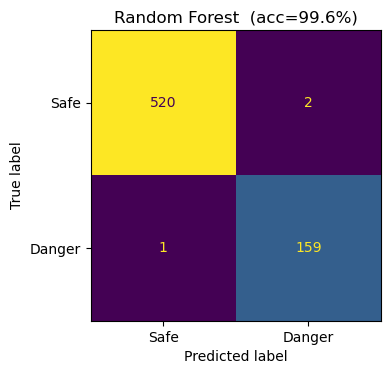

In [13]:
# Flatten (N, 15, 5) → (N, 75)
X_tr_rf = X_tr.reshape(len(X_tr), -1)
X_te_rf = X_te.reshape(len(X_te), -1)

t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight="balanced",          # match SNN's compute_class_weight
    random_state=42, n_jobs=-1)
rf.fit(X_tr_rf, y_tr)
RF_TRAIN_T = time.time() - t0

rf.predict(X_te_rf[:5])               # warm-up JIT
t0 = time.time()
rf_pred   = rf.predict(X_te_rf)
RF_INF_MS = (time.time() - t0) / len(y_te) * 1000

RF_ACC   = accuracy_score(y_te, rf_pred)
RF_CM    = confusion_matrix(y_te, rf_pred)
RF_REP   = classification_report(y_te, rf_pred,
               target_names=["Safe","Danger"], digits=4, output_dict=True)
RF_NODES = sum(t.tree_.node_count for t in rf.estimators_)

print(f"Random Forest — HORIZON={ph}")
print(f"  Accuracy      : {RF_ACC*100:.2f}%")
print(f"  Safe  P/R/F1  : "
      f"{RF_REP['Safe']['precision']:.4f} / "
      f"{RF_REP['Safe']['recall']:.4f} / "
      f"{RF_REP['Safe']['f1-score']:.4f}")
print(f"  Danger P/R/F1 : "
      f"{RF_REP['Danger']['precision']:.4f} / "
      f"{RF_REP['Danger']['recall']:.4f} / "
      f"{RF_REP['Danger']['f1-score']:.4f}")
print(f"  Inference     : {RF_INF_MS:.4f} ms/sample")
print(f"  Train time    : {RF_TRAIN_T:.2f} s")
print(f"  Total nodes   : {RF_NODES:,}")

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(RF_CM, display_labels=["Safe","Danger"]).plot(
    ax=ax, colorbar=False)
ax.set_title(f"Random Forest  (acc={RF_ACC*100:.1f}%)")
plt.tight_layout(); plt.show()


### 12.3  LSTM Baseline
2-layer LSTM over 15 timesteps. Always dense — no spike encoding.


LSTM parameters: 13,506
Class weights: Safe=0.606  Danger=2.849
  Epoch  5/20  loss=0.0406
  Epoch 10/20  loss=0.0295
  Epoch 15/20  loss=0.0257
  Epoch 20/20  loss=0.0183

LSTM — HORIZON=0
  Accuracy      : 99.56%
  Danger Recall : 1.0000
  Inference     : 0.0402 ms/sample
  Train time    : 7.3 s

              precision    recall  f1-score   support

        Safe     1.0000    0.9943    0.9971       522
      Danger     0.9816    1.0000    0.9907       160

    accuracy                         0.9956       682
   macro avg     0.9908    0.9971    0.9939       682
weighted avg     0.9957    0.9956    0.9956       682



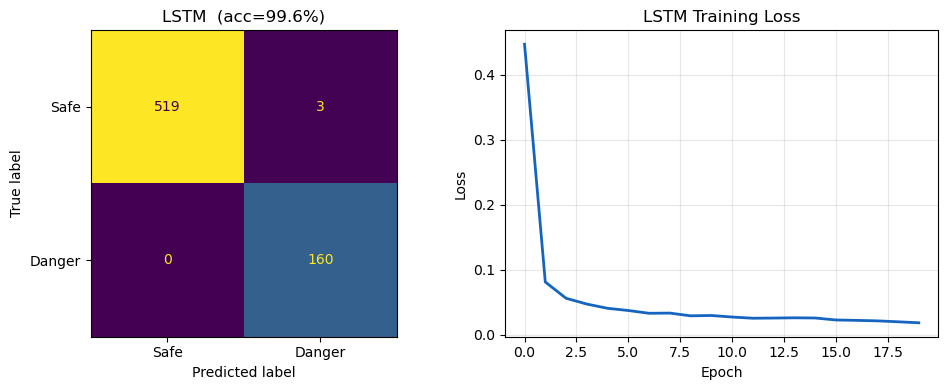

In [14]:
class LSTMBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(5, 32, num_layers=2, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])          # last timestep only

lstm_model = LSTMBaseline().to(device)
LSTM_PARAMS = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM parameters: {LSTM_PARAMS:,}")

# Class-weighted loss — danger is the minority class so it gets higher weight
from sklearn.utils.class_weight import compute_class_weight
cw   = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
cw_t = torch.tensor(cw, dtype=torch.float32).to(device)
print(f"Class weights: Safe={cw[0]:.3f}  Danger={cw[1]:.3f}")
criterion = nn.CrossEntropyLoss(weight=cw_t)

opt = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.5)

# DataLoaders — explicit dtypes to avoid silent type errors
tr_ld = DataLoader(
    TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                  torch.tensor(y_tr, dtype=torch.long)),
    batch_size=64, shuffle=True)
te_ld = DataLoader(
    TensorDataset(torch.tensor(X_te, dtype=torch.float32),
                  torch.tensor(y_te, dtype=torch.long)),
    batch_size=64, shuffle=False)

NUM_EPOCHS = 20
t0 = time.time()
lstm_losses = []
for ep in range(NUM_EPOCHS):
    lstm_model.train(); ep_loss = 0
    for Xb, yb in tr_ld:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = criterion(lstm_model(Xb), yb)
        loss.backward(); opt.step()
        ep_loss += loss.item()
    sch.step()
    lstm_losses.append(ep_loss / len(tr_ld))
    if (ep+1) % 5 == 0:
        print(f"  Epoch {ep+1:>2}/{NUM_EPOCHS}  loss={lstm_losses[-1]:.4f}")
LSTM_TRAIN_T = time.time() - t0

lstm_model.eval()
yp_l, yt_l, lstm_times = [], [], []
with torch.no_grad():
    for Xb, yb in te_ld:
        t0 = time.time()
        out = lstm_model(Xb.to(device))
        lstm_times.append((time.time()-t0) * 1000 / len(Xb))
        yp_l.extend(out.argmax(1).cpu().numpy())
        yt_l.extend(yb.numpy())

LSTM_INF_MS = float(np.mean(lstm_times))
LSTM_ACC  = accuracy_score(yt_l, yp_l)
LSTM_CM   = confusion_matrix(yt_l, yp_l)
LSTM_REP  = classification_report(yt_l, yp_l,
                target_names=["Safe","Danger"], digits=4, output_dict=True)

print(f"\nLSTM — HORIZON={ph}")
print(f"  Accuracy      : {LSTM_ACC*100:.2f}%")
print(f"  Danger Recall : {LSTM_REP['Danger']['recall']:.4f}")
print(f"  Inference     : {LSTM_INF_MS:.4f} ms/sample")
print(f"  Train time    : {LSTM_TRAIN_T:.1f} s")
print()
print(classification_report(yt_l, yp_l, target_names=["Safe","Danger"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(LSTM_CM, display_labels=["Safe","Danger"]).plot(
    ax=axes[0], colorbar=False)
axes[0].set_title(f"LSTM  (acc={LSTM_ACC*100:.1f}%)")
axes[1].plot(lstm_losses, color="#1565C0", lw=2)
axes[1].set(xlabel="Epoch", ylabel="Loss", title="LSTM Training Loss")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 12.4  MLP Baseline
Feedforward network on flattened 75-feature input. Single-pass, no temporal processing.


MLP parameters: 9,410
  Epoch  5/20  loss=0.0637
  Epoch 10/20  loss=0.0484
  Epoch 15/20  loss=0.0376
  Epoch 20/20  loss=0.0396

MLP — HORIZON=0
  Accuracy      : 97.36%
  Danger Recall : 1.0000
  Inference     : 0.0049 ms/sample
  Train time    : 3.9 s

              precision    recall  f1-score   support

        Safe     1.0000    0.9655    0.9825       522
      Danger     0.8989    1.0000    0.9467       160

    accuracy                         0.9736       682
   macro avg     0.9494    0.9828    0.9646       682
weighted avg     0.9763    0.9736    0.9741       682



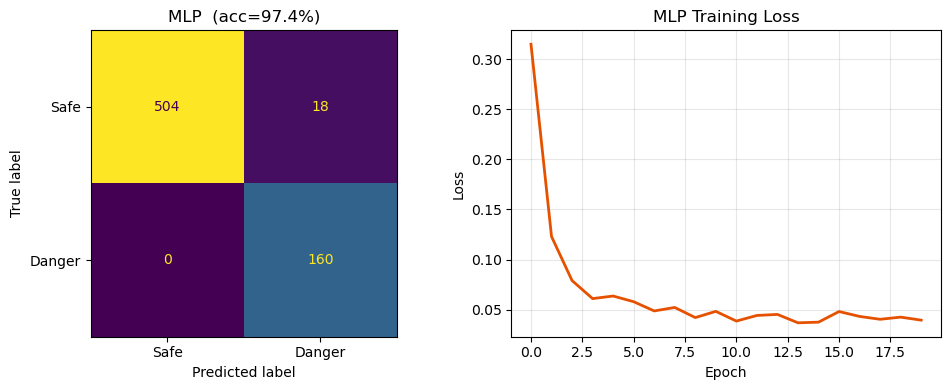

In [15]:
class MLPBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(75, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 2))
    def forward(self, x):
        return self.net(x.reshape(x.size(0), -1))

mlp_model = MLPBaseline().to(device)
MLP_PARAMS = sum(p.numel() for p in mlp_model.parameters())
print(f"MLP parameters: {MLP_PARAMS:,}")

# Reuse criterion and loaders from Cell 29 (same class weights, same data)
opt = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.StepLR(opt, step_size=8, gamma=0.5)

t0 = time.time()
mlp_losses = []
for ep in range(NUM_EPOCHS):
    mlp_model.train(); ep_loss = 0
    for Xb, yb in tr_ld:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = criterion(mlp_model(Xb), yb)
        loss.backward(); opt.step()
        ep_loss += loss.item()
    sch.step()
    mlp_losses.append(ep_loss / len(tr_ld))
    if (ep+1) % 5 == 0:
        print(f"  Epoch {ep+1:>2}/{NUM_EPOCHS}  loss={mlp_losses[-1]:.4f}")
MLP_TRAIN_T = time.time() - t0

mlp_model.eval()
yp_m, yt_m, mlp_times = [], [], []
with torch.no_grad():
    for Xb, yb in te_ld:
        t0 = time.time()
        out = mlp_model(Xb.to(device))
        mlp_times.append((time.time()-t0) * 1000 / len(Xb))
        yp_m.extend(out.argmax(1).cpu().numpy())
        yt_m.extend(yb.numpy())

MLP_INF_MS = float(np.mean(mlp_times))
MLP_ACC  = accuracy_score(yt_m, yp_m)
MLP_CM   = confusion_matrix(yt_m, yp_m)
MLP_REP  = classification_report(yt_m, yp_m,
               target_names=["Safe","Danger"], digits=4, output_dict=True)

print(f"\nMLP — HORIZON={ph}")
print(f"  Accuracy      : {MLP_ACC*100:.2f}%")
print(f"  Danger Recall : {MLP_REP['Danger']['recall']:.4f}")
print(f"  Inference     : {MLP_INF_MS:.4f} ms/sample")
print(f"  Train time    : {MLP_TRAIN_T:.1f} s")
print()
print(classification_report(yt_m, yp_m, target_names=["Safe","Danger"], digits=4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(MLP_CM, display_labels=["Safe","Danger"]).plot(
    ax=axes[0], colorbar=False)
axes[0].set_title(f"MLP  (acc={MLP_ACC*100:.1f}%)")
axes[1].plot(mlp_losses, color="#E65100", lw=2)
axes[1].set(xlabel="Epoch", ylabel="Loss", title="MLP Training Loss")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 12.5  SNN Evaluation
Re-run inference on the same test set using the already-trained SNN from `results[0]`.


SNN parameters: 1,474
SNN — HORIZON=0  threshold=0.55
  Accuracy      : 92.96%
  Danger Recall : 0.9062  ← real obstacles caught
  Inference     : 0.3397 ms/sample

              precision    recall  f1-score   support

        Safe     0.9702    0.9368    0.9532       522
      Danger     0.8146    0.9062    0.8580       160

    accuracy                         0.9296       682
   macro avg     0.8924    0.9215    0.9056       682
weighted avg     0.9337    0.9296    0.9309       682



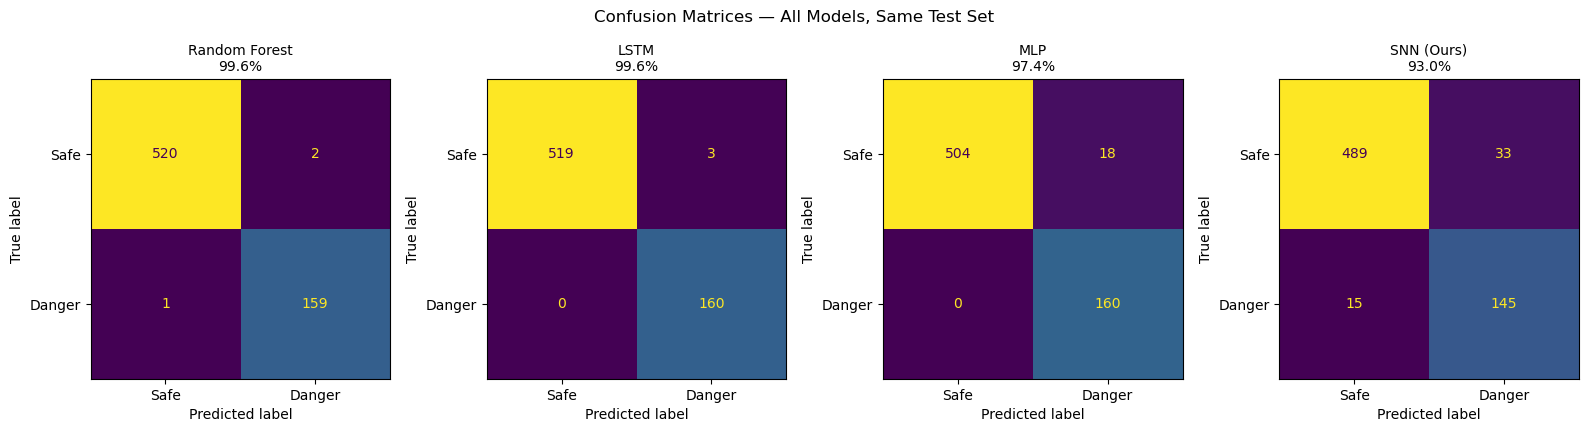

In [16]:
SNN_PARAMS = sum(p.numel() for p in SNN_MODEL.parameters())
print(f"SNN parameters: {SNN_PARAMS:,}")

DANGER_THR = 0.55      # same threshold as snn_inference.py
yp_s, yt_s, snn_times = [], [], []

with torch.no_grad():
    for i in range(0, len(X_te), 64):
        Xb = torch.tensor(X_te[i:i+64], dtype=torch.float32).to(device)
        t0 = time.time()
        mem_out = SNN_MODEL(Xb)[-1]        # (T,B,2) → last timestep → (B,2)
        snn_times.append((time.time()-t0) * 1000 / len(Xb))
        probs = torch.softmax(mem_out, dim=1)
        preds = (probs[:, 1] >= DANGER_THR).long()
        yp_s.extend(preds.cpu().numpy())
        yt_s.extend(y_te[i:i+64].tolist())   # y_te is numpy int64, convert cleanly

SNN_INF_MS = float(np.mean(snn_times))
SNN_ACC  = accuracy_score(yt_s, yp_s)
SNN_CM   = confusion_matrix(yt_s, yp_s)
SNN_REP  = classification_report(yt_s, yp_s,
               target_names=["Safe","Danger"], digits=4, output_dict=True)

print(f"SNN — HORIZON={ph}  threshold={DANGER_THR}")
print(f"  Accuracy      : {SNN_ACC*100:.2f}%")
print(f"  Danger Recall : {SNN_REP['Danger']['recall']:.4f}  ← real obstacles caught")
print(f"  Inference     : {SNN_INF_MS:.4f} ms/sample")
print()
print(classification_report(yt_s, yp_s, target_names=["Safe","Danger"], digits=4))

# All 4 confusion matrices side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, cm, name, acc in zip(
        axes,
        [RF_CM,   LSTM_CM,   MLP_CM,   SNN_CM],
        ["Random Forest", "LSTM", "MLP", "SNN (Ours)"],
        [RF_ACC,  LSTM_ACC,  MLP_ACC,  SNN_ACC]):
    ConfusionMatrixDisplay(cm, display_labels=["Safe","Danger"]).plot(
        ax=ax, colorbar=False)
    ax.set_title(f"{name}\n{acc*100:.1f}%", fontsize=10)
plt.suptitle("Confusion Matrices — All Models, Same Test Set",
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


### 13  Spike Sparsity & Computational Cost
Measure spike activity on real test windows, then compute FLOPs using the **same formula** for every model.


Spike Sparsity Analysis  (682 test windows)
  Max possible spikes / window : 150
  Avg active spikes / window   : 11.9
  Spike rate   (active)        : 8.50%
  Sparsity     (silent)        : 91.50%
  → SNN skips 92% of multiply-accumulate operations

FLOPs per inference  (same formula, all models)
  Model                    FLOPs   vs SNN sparse
  ──────────────────────────────────────────────
  RF                       2,000         0× more
  MLP                     18,048         3× more
  SNN dense               42,240         6× more
  SNN ★                    6,559      ← baseline
  LSTM                   387,968        59× more

  Sparsity removes 84% of SNN ops vs dense SNN
  SNN uses 98% fewer FLOPs than LSTM


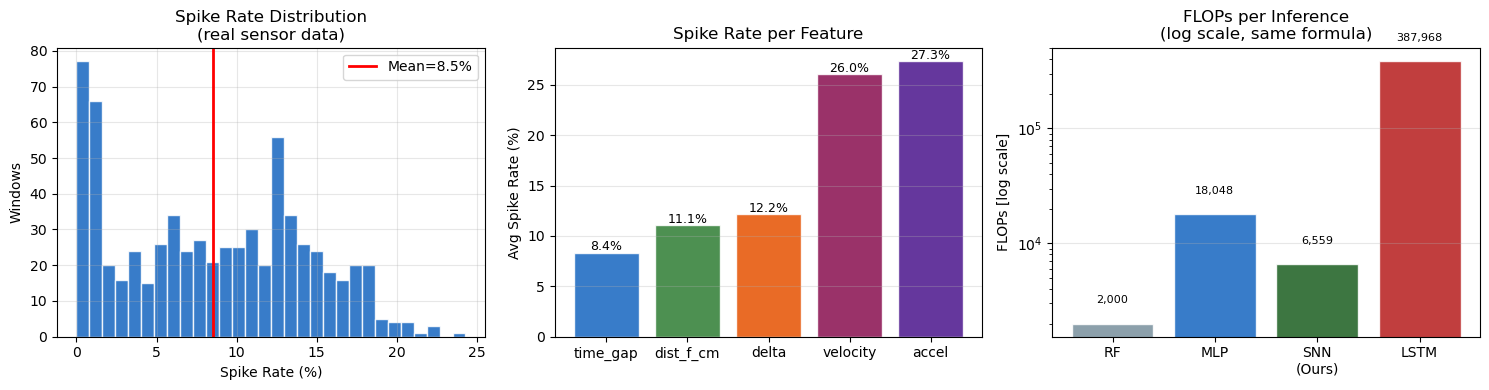

In [17]:
# ═══════════════════════════════════════════════════════════
# 13.1  Spike sparsity — measured on real test windows
# ═══════════════════════════════════════════════════════════
THRESHOLD = 0.5     # same as delta_encoder in training
spike_rates, spike_counts = [], []

for win in X_te:                   # (N, 15, 5) scaled windows
    ref = win[0].copy()
    sp = 0; total = 0
    for t in range(1, WINDOW_SIZE):
        diff  = win[t] - ref
        on    = (diff >=  THRESHOLD).astype(float)
        off   = (diff <= -THRESHOLD).astype(float)
        fired = (on + off) > 0
        ref[fired] = win[t][fired]
        sp    += int(on.sum() + off.sum())
        total += 10                 # 5 features × 2 channels (ON/OFF)
    spike_rates.append(sp / total)
    spike_counts.append(sp)

SPIKE_RATE = float(np.mean(spike_rates))
SPARSITY   = 1.0 - SPIKE_RATE
AVG_SPIKES = float(np.mean(spike_counts))

print(f"Spike Sparsity Analysis  ({len(X_te)} test windows)")
print(f"  Max possible spikes / window : {WINDOW_SIZE * 10}")
print(f"  Avg active spikes / window   : {AVG_SPIKES:.1f}")
print(f"  Spike rate   (active)        : {SPIKE_RATE*100:.2f}%")
print(f"  Sparsity     (silent)        : {SPARSITY*100:.2f}%")
print(f"  → SNN skips {SPARSITY*100:.0f}% of multiply-accumulate operations")

# ═══════════════════════════════════════════════════════════
# 13.2  FLOPs — identical formula applied to every model
# ═══════════════════════════════════════════════════════════
T    = WINDOW_SIZE   # 15 timesteps
H    = 32            # SNN/LSTM hidden size
H_MLP = 64          # MLP hidden size (MLPBaseline uses 64, not 32)
IN   = 5             # input features
OUT  = 2             # classes

# SNN: FC ops scale with spike rate; LIF ops always execute
SNN_FL_SPARSE = int(
    IN*2 * H    * 2 * T * SPIKE_RATE  +   # fc1 (sparse)
    H           * 3 * T                +   # lif1 (always: decay+thr+reset)
    H    * H    * 2 * T * SPIKE_RATE  +   # fc2 (sparse)
    H           * 3 * T                +   # lif2 (always)
    H    * OUT  * 2 * T * SPIKE_RATE  +   # fc3 (sparse)
    OUT         * 3 * T                    # lif3 (always)
)
SNN_FL_DENSE = int((IN*2*H + H*H + H*OUT) * 2 * T)   # hypothetical dense SNN

# LSTM: 4 gates, 2 layers, always dense
LSTM_FL = (4*(IN+H)*H*2*T) + (4*(H+H)*H*2*T) + (H*OUT*2)

# MLP: flatten → 3 FC layers, single pass (no time loop), hidden=64
MLP_FL  = (IN*WINDOW_SIZE*H_MLP + H_MLP*H_MLP + H_MLP*OUT) * 2

# RF: avg tree depth × n_trees × (compare + branch)
RF_FL   = 10 * 100 * 2

print(f"\nFLOPs per inference  (same formula, all models)")
print(f"  {'Model':<18}  {'FLOPs':>10}  {'vs SNN sparse':>14}")
print(f"  {'─'*46}")
for name, fl in [("RF",         RF_FL),
                  ("MLP",        MLP_FL),
                  ("SNN dense",  SNN_FL_DENSE),
                  ("SNN ★",      SNN_FL_SPARSE),
                  ("LSTM",       LSTM_FL)]:
    r = fl / SNN_FL_SPARSE
    tag = "← baseline" if "SNN ★" in name else f"{r:.0f}× more"
    print(f"  {name:<18}  {fl:>10,}  {tag:>14}")

print(f"\n  Sparsity removes {(1-SNN_FL_SPARSE/SNN_FL_DENSE)*100:.0f}% of SNN ops vs dense SNN")
print(f"  SNN uses {(1-SNN_FL_SPARSE/LSTM_FL)*100:.0f}% fewer FLOPs than LSTM")

# ── Spike histogram + per-feature rates + FLOPs bar ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(np.array(spike_rates)*100, bins=30,
             color="#1565C0", edgecolor="white", alpha=0.85)
axes[0].axvline(SPIKE_RATE*100, color="red", lw=2,
                label=f"Mean={SPIKE_RATE*100:.1f}%")
axes[0].set(xlabel="Spike Rate (%)", ylabel="Windows",
            title="Spike Rate Distribution\n(real sensor data)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

feat_names = ["time_gap","dist_f_cm","delta","velocity","accel"]
feat_rates = []
for fi in range(IN):
    rs = []
    for win in X_te:
        ref = win[0, fi]; s = 0
        for t in range(1, WINDOW_SIZE):
            if abs(win[t, fi] - ref) >= THRESHOLD:
                s += 1; ref = win[t, fi]
        rs.append(s / (WINDOW_SIZE - 1))
    feat_rates.append(float(np.mean(rs)) * 100)

cols = ["#1565C0","#2E7D32","#E65100","#880E4F","#4A148C"]
bars = axes[1].bar(feat_names, feat_rates, color=cols,
                   edgecolor="white", alpha=0.85)
axes[1].set(ylabel="Avg Spike Rate (%)", title="Spike Rate per Feature")
axes[1].grid(True, alpha=0.3, axis="y")
for b, v in zip(bars, feat_rates):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.2,
                 f"{v:.1f}%", ha="center", fontsize=9)

fl_models = ["RF","MLP","SNN\n(Ours)","LSTM"]
fl_vals   = [RF_FL, MLP_FL, SNN_FL_SPARSE, LSTM_FL]
fl_colors = ["#78909C","#1565C0","#1B5E20","#B71C1C"]
axes[2].bar(fl_models, fl_vals, color=fl_colors, edgecolor="white", alpha=0.85)
axes[2].set_yscale("log")
axes[2].set(ylabel="FLOPs [log scale]",
            title="FLOPs per Inference\n(log scale, same formula)")
axes[2].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(fl_vals):
    axes[2].text(i, v*1.5, f"{v:,}", ha="center", fontsize=8)

plt.tight_layout(); plt.show()


### 14  Energy, Power & AUV Mission Duration
Same Horowitz 2014 energy model applied to all models.


Energy per inference:
  Model               CPU/GPU (nJ)     Neuro HW (nJ)  vs LSTM
  ────────────────────────────────────────────────────────────
  RF                       3528.56                 —  -44.1%
  LSTM                     2448.33                 —  +0.0%
  MLP                       214.22                 —  +91.3%
  SNN  CPU ★                 31.93                 —  +98.7%
  SNN  Neuro ★                   —          0.008140  +100.0%

  SNN CPU   → 99% less energy than LSTM (same hardware)
  SNN Neuro → 100.0% less (neuromorphic chip — theoretical)
  Memory    : SNN 11B vs LSTM 4148B → 100% less data movement

Continuous power at 3.5 Hz:
  Model               Power (µW)
  ────────────────────────────────
  RF                    12.34996
  LSTM                   8.56916
  MLP                    0.74977
  SNN CPU                0.11176
  SNN Neuro              0.00003

AUV Mission Duration  (battery=74Wh, base=45.8W)
  Deployment                     AI Chip     Total    Dur

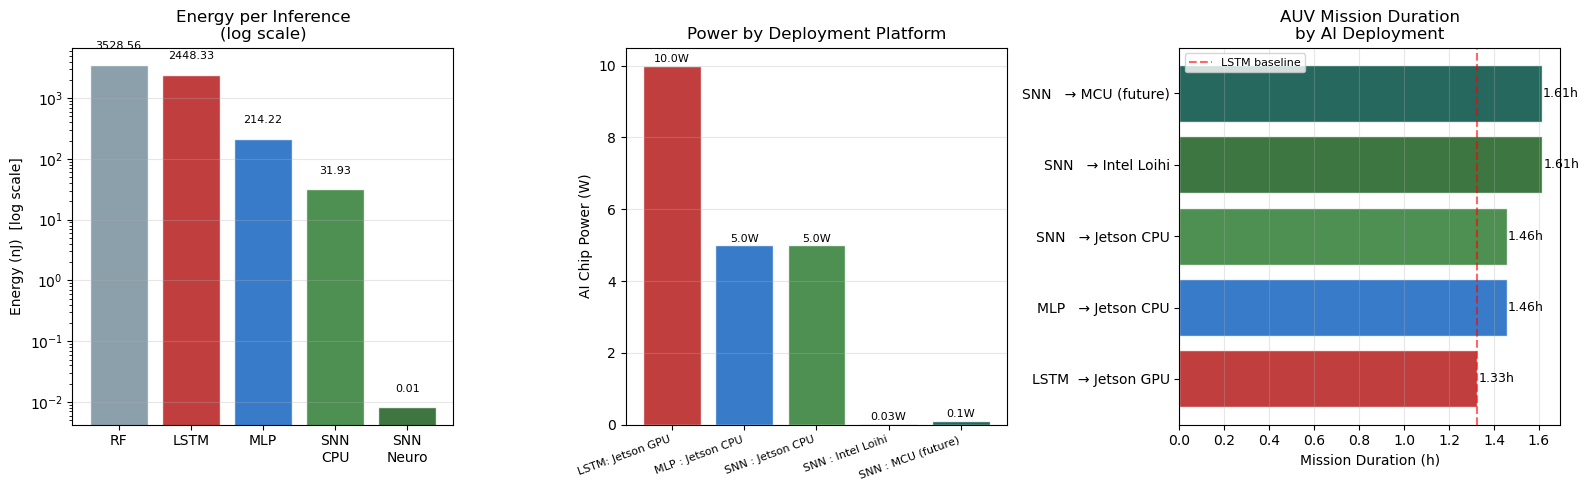


  Mission extension:  1.33h → 1.61h
  = +22% longer (17 extra minutes per dive)


In [18]:
# ═══════════════════════════════════════════════════════════
# 14.1  Energy per inference  (Horowitz 2014 model)
# ═══════════════════════════════════════════════════════════
# Constants (literature):
#   MAC on 45nm CMOS     : 4.6  pJ  — Horowitz, ISSCC 2014
#   DRAM read (32-bit)   : 640  pJ  — Horowitz, ISSCC 2014
#   Neuromorphic spike   : 0.1  pJ  — Merolla et al. Science 2014
MAC_PJ   = 4.6e-12
MEM_PJ   = 640e-12
SPIKE_PJ = 0.1e-12

# Memory transferred per inference (bytes)
RF_MEM   = int(IN*WINDOW_SIZE*4 + RF_NODES*4)   # features + node values
LSTM_MEM = (T*IN*4) + (T*H*4*2) + (OUT*4)        # input + 2 hidden states + out
MLP_MEM  = (IN*WINDOW_SIZE*4) + (H_MLP*4*2) + (OUT*4)  # input + 2 hidden + out
SNN_MEM  = int(AVG_SPIKES) * 1                   # 1 byte per spike (binary)

def energy(flops, mem_b):
    return flops * MAC_PJ + (mem_b / 4) * MEM_PJ

RF_E        = energy(RF_FL,        RF_MEM)
LSTM_E      = energy(LSTM_FL,      LSTM_MEM)
MLP_E       = energy(MLP_FL,       MLP_MEM)
SNN_E_CPU   = energy(SNN_FL_SPARSE, SNN_MEM)
# Neuromorphic HW: spike events at 0.1pJ + near-memory (1000× less DRAM)
SNN_E_NEURO = int(AVG_SPIKES) * SPIKE_PJ + SNN_MEM * MEM_PJ * 0.001

print("Energy per inference:")
print(f"  {'Model':<16}  {'CPU/GPU (nJ)':>14}  {'Neuro HW (nJ)':>16}  vs LSTM")
print(f"  {'─'*60}")
for name, ec, en in [
    ("RF",           RF_E,      None),
    ("LSTM",         LSTM_E,    None),
    ("MLP",          MLP_E,     None),
    ("SNN  CPU ★",   SNN_E_CPU, None),
    ("SNN  Neuro ★", None,      SNN_E_NEURO),
]:
    cs = f"{ec*1e9:.2f}" if ec   else "—"
    ns = f"{en*1e9:.6f}" if en   else "—"
    vs = f"{(1-(ec or en)/LSTM_E)*100:+.1f}%"
    print(f"  {name:<16}  {cs:>14}  {ns:>16}  {vs}")

print(f"\n  SNN CPU   → {(1-SNN_E_CPU/LSTM_E)*100:.0f}% less energy than LSTM (same hardware)")
print(f"  SNN Neuro → {(1-SNN_E_NEURO/LSTM_E)*100:.1f}% less (neuromorphic chip — theoretical)")
print(f"  Memory    : SNN {SNN_MEM}B vs LSTM {LSTM_MEM}B "
      f"→ {(1-SNN_MEM/LSTM_MEM)*100:.0f}% less data movement")

# ═══════════════════════════════════════════════════════════
# 14.2  Continuous power at sensor rate (3.5 Hz)
# ═══════════════════════════════════════════════════════════
SENSOR_HZ = 3.5

print(f"\nContinuous power at {SENSOR_HZ} Hz:")
print(f"  {'Model':<16}  {'Power (µW)':>12}")
print(f"  {'─'*32}")
for name, e in [("RF",RF_E),("LSTM",LSTM_E),("MLP",MLP_E),
                ("SNN CPU",SNN_E_CPU),("SNN Neuro",SNN_E_NEURO)]:
    print(f"  {name:<16}  {e*SENSOR_HZ*1e6:>12.5f}")

# ═══════════════════════════════════════════════════════════
# 14.3  AUV mission duration
# ═══════════════════════════════════════════════════════════
BATTERY_WH = 5000/1000 * 14.8    # 74 Wh  (5Ah @ 14.8V LiPo)
AUV_BASE_W = 45.8                 # thrusters 45W + sensors 0.5W + comms 0.3W

DEPLOYMENTS = [
    ("LSTM  → Jetson GPU",   10.000, "#B71C1C"),
    ("MLP   → Jetson CPU",    5.000, "#1565C0"),
    ("SNN   → Jetson CPU",    5.000, "#2E7D32"),
    ("SNN   → Intel Loihi",   0.030, "#1B5E20"),
    ("SNN   → MCU (future)",  0.100, "#004D40"),
]

print(f"\nAUV Mission Duration  (battery={BATTERY_WH:.0f}Wh, base={AUV_BASE_W}W)")
print(f"  {'Deployment':<28}  {'AI Chip':>8}  {'Total':>8}  {'Duration':>10}  vs LSTM")
print(f"  {'─'*70}")
base_h = None
hours_all, labels_all, colors_all = [], [], []
for name, ai_w, col in DEPLOYMENTS:
    total = AUV_BASE_W + ai_w
    h     = BATTERY_WH / total
    if base_h is None: base_h = h
    gain  = (h - base_h) / base_h * 100
    gs    = f"+{gain:.0f}%" if gain > 0 else "baseline"
    print(f"  {name:<28}  {ai_w:>7.3f}W  {total:>7.2f}W  {h:>9.2f}h  {gs}")
    hours_all.append(h); labels_all.append(name); colors_all.append(col)

# ═══════════════════════════════════════════════════════════
# 14.4  Charts
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

e_names  = ["RF","LSTM","MLP","SNN\nCPU","SNN\nNeuro"]
e_vals   = [RF_E*1e9, LSTM_E*1e9, MLP_E*1e9, SNN_E_CPU*1e9, SNN_E_NEURO*1e9]
e_colors = ["#78909C","#B71C1C","#1565C0","#2E7D32","#1B5E20"]
axes[0].bar(e_names, e_vals, color=e_colors, edgecolor="white", alpha=0.85)
axes[0].set_yscale("log")
axes[0].set(ylabel="Energy (nJ)  [log scale]",
            title="Energy per Inference\n(log scale)")
axes[0].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(e_vals):
    axes[0].text(i, v*1.8, f"{v:.2f}", ha="center", fontsize=8)

chip_names = [d[0].replace("  →", ":") for d in DEPLOYMENTS]
chip_w     = [d[1] for d in DEPLOYMENTS]
chip_cols  = [d[2] for d in DEPLOYMENTS]
axes[1].bar(range(len(chip_names)), chip_w, color=chip_cols,
            edgecolor="white", alpha=0.85)
axes[1].set_xticks(range(len(chip_names)))
axes[1].set_xticklabels(chip_names, rotation=20, ha="right", fontsize=8)
axes[1].set(ylabel="AI Chip Power (W)", title="Power by Deployment Platform")
axes[1].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(chip_w):
    axes[1].text(i, v+0.1, f"{v}W", ha="center", fontsize=8)

bars = axes[2].barh(labels_all, hours_all, color=colors_all,
                    edgecolor="white", alpha=0.85)
axes[2].axvline(base_h, color="red", lw=1.5, ls="--", alpha=0.6,
                label="LSTM baseline")
axes[2].set(xlabel="Mission Duration (h)",
            title="AUV Mission Duration\nby AI Deployment")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3, axis="x")
for bar, v in zip(bars, hours_all):
    axes[2].text(v+0.005, bar.get_y()+bar.get_height()/2,
                 f"{v:.2f}h", va="center", fontsize=9)
plt.tight_layout(); plt.show()

snn_loihi_h = BATTERY_WH / (AUV_BASE_W + 0.030)
print(f"\n  Mission extension:  {base_h:.2f}h → {snn_loihi_h:.2f}h")
print(f"  = +{(snn_loihi_h-base_h)/base_h*100:.0f}% longer "
      f"({(snn_loihi_h-base_h)*60:.0f} extra minutes per dive)")


### 15  Final Results Table
All models, same test set, same criteria. Copy these numbers into your presentation.


In [19]:
print("=" * 72)
print(f"  COMPLETE EVALUATION — HORIZON={ph}, {len(y_te)} test windows")
print("=" * 72)

def r(label, *vals):
    row = f"  {label:<26}"
    for v in vals: row += f"  {str(v):>12}"
    print(row)

r("Metric",           "RF",        "LSTM",       "MLP",        "SNN (Ours)")
print("  " + "─" * 68)
r("Accuracy",
  f"{RF_ACC*100:.2f}%",    f"{LSTM_ACC*100:.2f}%",
  f"{MLP_ACC*100:.2f}%",   f"{SNN_ACC*100:.2f}%")
r("Safe F1",
  f"{RF_REP['Safe']['f1-score']:.4f}",
  f"{LSTM_REP['Safe']['f1-score']:.4f}",
  f"{MLP_REP['Safe']['f1-score']:.4f}",
  f"{SNN_REP['Safe']['f1-score']:.4f}")
r("Danger Recall ★",
  f"{RF_REP['Danger']['recall']:.4f}",
  f"{LSTM_REP['Danger']['recall']:.4f}",
  f"{MLP_REP['Danger']['recall']:.4f}",
  f"{SNN_REP['Danger']['recall']:.4f}")
r("Danger F1",
  f"{RF_REP['Danger']['f1-score']:.4f}",
  f"{LSTM_REP['Danger']['f1-score']:.4f}",
  f"{MLP_REP['Danger']['f1-score']:.4f}",
  f"{SNN_REP['Danger']['f1-score']:.4f}")
print("  " + "─" * 68)
r("Parameters",
  f"{RF_NODES:,} nodes", f"{LSTM_PARAMS:,}", f"{MLP_PARAMS:,}", f"{SNN_PARAMS:,}")
r("FLOPs / inference",
  f"{RF_FL:,}", f"{LSTM_FL:,}", f"{MLP_FL:,}", f"{SNN_FL_SPARSE:,}")
r("Spike sparsity",     "N/A",  "N/A",  "N/A", f"{SPARSITY*100:.1f}%")
r("Memory / inf (B)",
  f"{RF_MEM:,}", f"{LSTM_MEM:,}", f"{MLP_MEM:,}", f"{SNN_MEM:,}")
print("  " + "─" * 68)
r("Energy CPU (nJ)",
  f"{RF_E*1e9:.1f}",   f"{LSTM_E*1e9:.1f}",
  f"{MLP_E*1e9:.1f}",  f"{SNN_E_CPU*1e9:.2f}")
r("Energy Neuro (nJ)", "N/A", "N/A", "N/A", f"{SNN_E_NEURO*1e9:.6f}")
r("Energy save vs LSTM",
  f"{(1-RF_E/LSTM_E)*100:.0f}%",  "baseline",
  f"{(1-MLP_E/LSTM_E)*100:.0f}%", f"{(1-SNN_E_CPU/LSTM_E)*100:.0f}% (CPU)")
print("  " + "─" * 68)
r("Inf latency (ms)",
  f"{RF_INF_MS:.3f}", f"{LSTM_INF_MS:.3f}", f"{MLP_INF_MS:.3f}", f"{SNN_INF_MS:.3f}")
r("Mission (Jetson CPU)", "—",
  f"{BATTERY_WH/(AUV_BASE_W+10):.2f}h",
  f"{BATTERY_WH/(AUV_BASE_W+5):.2f}h",
  f"{BATTERY_WH/(AUV_BASE_W+5):.2f}h")
r("Mission (Loihi)",  "—", "—", "—",
  f"{BATTERY_WH/(AUV_BASE_W+0.03):.2f}h")
r("Neuromorphic HW?", "No", "No", "No", "Yes")
print("=" * 72)

print("\n  KEY NUMBERS FOR YOUR PRESENTATION:")
print(f"  1. Accuracy    SNN {SNN_ACC*100:.2f}%  vs  LSTM {LSTM_ACC*100:.2f}%")
print(f"  2. Parameters  SNN {SNN_PARAMS:,}  vs  LSTM {LSTM_PARAMS:,}"
      f"  ({LSTM_PARAMS//SNN_PARAMS}× smaller)")
print(f"  3. FLOPs       SNN {SNN_FL_SPARSE:,}  vs  LSTM {LSTM_FL:,}"
      f"  ({(1-SNN_FL_SPARSE/LSTM_FL)*100:.0f}% fewer)")
print(f"  4. Energy(CPU) SNN saves {(1-SNN_E_CPU/LSTM_E)*100:.0f}% vs LSTM")
print(f"  5. Mission     +{(snn_loihi_h/base_h-1)*100:.0f}%"
      f" longer with SNN on Loihi vs LSTM on Jetson GPU")


  COMPLETE EVALUATION — HORIZON=0, 682 test windows
  Metric                                RF          LSTM           MLP    SNN (Ours)
  ────────────────────────────────────────────────────────────────────
  Accuracy                          99.56%        99.56%        97.36%        92.96%
  Safe F1                           0.9971        0.9971        0.9825        0.9532
  Danger Recall ★                   0.9938        1.0000        1.0000        0.9062
  Danger F1                         0.9907        0.9907        0.9467        0.8580
  ────────────────────────────────────────────────────────────────────
  Parameters                   5,424 nodes        13,506         9,410         1,474
  FLOPs / inference                  2,000       387,968        18,048         6,559
  Spike sparsity                       N/A           N/A           N/A         91.5%
  Memory / inf (B)                  21,996         4,148           820            11
  ───────────────────────────────────────